In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from keras.datasets.mnist import load_data
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Reshape
from keras.layers import Flatten
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Dropout
import matplotlib.pyplot as plt


In [4]:
print(tf.__version__)
print(keras.__version__)

2.19.0
3.9.2


In [5]:
def discriminator(in_shape = (784,)):
    model = Sequential()
    model.add(keras.Input(shape=in_shape))
    model.add(keras.layers.Dense(512,activation='leaky_relu'))
    model.add(Dropout(0.3))
    model.add(keras.layers.Dense(128,activation='leaky_relu'))
    model.add(Dropout(0.3))
    # model.add(keras.layers.Dense(8,activation='leaky_relu'))
    model.add(keras.layers.Dense(1,activation='sigmoid'))

    model.compile(loss = 'binary_crossentropy',
                  optimizer = Adam(learning_rate = 0.0002,beta_1=0.5),
                  metrics=['accuracy'])
    return model

In [6]:
def generator(latent_dim):
    model = Sequential()
    model.add(keras.Input(shape=(latent_dim,)))
    model.add(keras.layers.Dense(128,activation='leaky_relu'))
    model.add(keras.layers.Dense(256,activation='leaky_relu'))
    model.add(keras.layers.Dense(512,activation='leaky_relu'))
    model.add(keras.layers.Dense(784,activation='tanh'))

    model.compile(loss = 'mse',
                  optimizer = Adam(learning_rate = 0.0005),
                  metrics=['accuracy'])
    return model

In [7]:
def gan_model(g_model,d_model):
    model = Sequential()
    model.add(g_model)
    model.add(d_model)

    model.compile(loss = 'binary_crossentropy',
                  optimizer = Adam(learning_rate = 0.0005,beta_1=0.5),
                  metrics=['accuracy'])
    return model

In [8]:
def load_real_data():
    (X_train,_),(_,_) = load_data()
    X_train = X_train.astype('float32') - 127.5
    return X_train.reshape((-1,784))/127.5

In [9]:
def generate_real_samples(data,n_sample=100):
    ix = np.random.randint(0,data.shape[0],n_sample)
    X = data[ix]
    y = np.ones((n_sample,1))*0.9
    return X,y

In [10]:
def generate_random_variable(latent_dim,n_sample=100):
    return np.random.randn(n_sample,latent_dim)

In [11]:
def generate_fake_samples(g_model,latent_dim,n_sample=100):
    rv = generate_random_variable(latent_dim,n_sample)
    X = g_model.predict(rv)
    y = np.zeros((n_sample,1))
    return X,y

In [18]:
def viz_plot(examples, epoch, n=10):
  for i in range(n * n):
    plt.subplot(n, n, 1+i)
    plt.axis('off')
    plt.imshow(examples[i].reshape((28,28)), interpolation='nearest',cmap = 'gray')
  filename = 'ds_lec1/t10k-images.idx3-ubyte' % (epoch+1)
  plt.savefig(filename)
  plt.close()

  return plt

In [19]:
def summary(g_model, d_model, dataset, latent_dim, epoch, n_samples = 100):
  X_real, y_real = generate_real_samples(dataset, n_samples)

  _, acc_real = d_model.evaluate(X_real, y_real, verbose = 0)

  X_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)

  _, acc_fake = d_model.evaluate(X_fake, y_fake, verbose = 0)

  print('> Accuracy real: %.0f%%, fake: %0.0f%%' % (acc_real*100, acc_fake*100))

  pyplot = viz_plot(X_fake, epoch)

  return pyplot

In [20]:
def train(g_model,d_model,gan_model,data,latent_dim,epochs=50,batch_size=256):
    nbatch = data.shape[0]//batch_size
    half_batch = batch_size//2
    pyplot = []
    for e in range(epochs):
        for bn in range(nbatch):

            x_real,y_real = generate_real_samples(data,half_batch)
            x_fake,y_fake = generate_fake_samples(g_model,latent_dim,half_batch)

            d_model.trainable = True
            r_loss,_ = d_model.train_on_batch(x_real,y_real)
            f_loss,_ = d_model.train_on_batch(x_fake,y_fake)

            d_loss = 0.5*r_loss+0.5*f_loss

            d_model.trainable = False
            x_rv = generate_random_variable(latent_dim,batch_size)
            y = np.ones((batch_size,1))

            g_loss,_ = gan_model.train_on_batch(x_rv,y)
            # print(f">{e+1} g={g_loss} d={d_loss}")
        print('> %d, %d/%d, d = %.3f, g=%.3f' % (e+1, bn+1, nbatch, d_loss, g_loss))
        if e%10 == 0:
            pyplot.append(summary(g_model,d_model,data,latent_dim,e+1,batch_size))
    return pyplot
        

> 1, 234/234, d = 0.687, g=0.790
> Accuracy real: 0%, fake: 2%


TypeError: not all arguments converted during string formatting

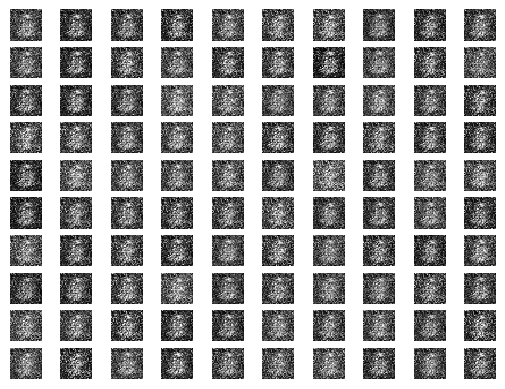

In [21]:
keras.utils.disable_interactive_logging()
latent_dim = 100
g_model = generator(latent_dim)
d_model = discriminator()
gm = gan_model(g_model,d_model)
data = load_real_data()
plot = train(g_model,d_model,gm,data,latent_dim)
keras.utils.enable_interactive_logging()